# TikTok Brand Analytics — Executive Business Report
## Nike vs. Adidas · From Attention to Audience Response

### The stakeholder question
**What kinds of TikTok content earn attention, how commercial are those messages, who carries them, and how does the audience respond?**

This report condenses the full analytical work into a **5–10 minute decision story**.  
The detailed notebooks remain the evidence trail; this notebook surfaces only the findings that change a business decision.

### Storyline
**1. Earn attention → 2. Carry commercial intent → 3. Choose the messenger → 4. Read the response → 5. Decide what to test**

> **Scope.** 4,457 search-visible public Nike and Adidas TikTok videos, including official accounts and creator content. Search results are algorithmically ranked, so findings describe this collected sample rather than TikTok as a whole. All findings are descriptive or predictive associations, not causal lift.


---
# Executive Summary

### One story, four lenses

| Business question | What the analysis says | Decision implication |
|---|---|---|
| **1 · What earns attention?** | Adidas is more lifestyle / styling / OOTD-oriented; Nike is more technical / performance / promotional. Their strongest relative content territories differ. | Optimize against each brand's own baseline rather than copy one universal “winning format.” |
| **2 · Does stronger selling create stronger content?** | Explicit commerce cues are rare (96.5% None). Nike is more commerce-oriented, but stronger commerce intensity does not consistently correspond to stronger engagement. | Treat commerce as a selective creative layer—not as a default recipe for engagement. |
| **3 · Who should carry the message?** | Creator scale alone is a weak guide. UGC has higher median BRI; collaboration is above baseline, but creator × content fit matters. | Match creator profile to content strategy rather than optimizing follower count alone. |
| **4 · How does the audience respond?** | Adidas has warmer overall comments in the high-engagement subsample, but product review, fit, availability and product-line differences reveal localized strengths and friction. | Diagnose audience response at topic/product level rather than declare one brand a sentiment “winner.” |

### Executive conclusion
The strongest signal is **fit**: content strategy, commercial intent, creator choice, and audience response need to be evaluated together. The analysis supports a **test-and-learn content strategy**, not a universal viral formula.


---
# 1 · EARN ATTENTION
## The brands do not win in the same content territory

### Business question
**Which content directions appear strongest for each brand—not just most common?**

The sample shows a clear strategic contrast:

- **Adidas** is more concentrated in **Lifestyle / Styling / GRWM / OOTD**.
- **Nike** is more concentrated in **Technical / Performance / Sports-action / Promotional** content.
- Overall, Adidas has the higher median WER in this sample.
- Within each brand, the stronger territories differ:
  - **Adidas Vibe / OOTD:** median WER ≈ **0.85%** vs brand baseline ≈ **0.70%** → **BRI 1.21×**
  - **Nike Tutorial / Utility:** median WER ≈ **0.66%** vs brand baseline ≈ **0.59%** → **BRI 1.11×**
  - **Collaboration:** above baseline for both brands → Adidas **1.12×**, Nike **1.13×**

### The decision
**Do not ask “what format wins TikTok?” Ask “what content territory earns above-baseline engagement for this brand?”**

### Visual to show
A compact **Brand × Content relative-performance chart**.  
Keep the full crosstabs and significance tests in the supporting notebook.


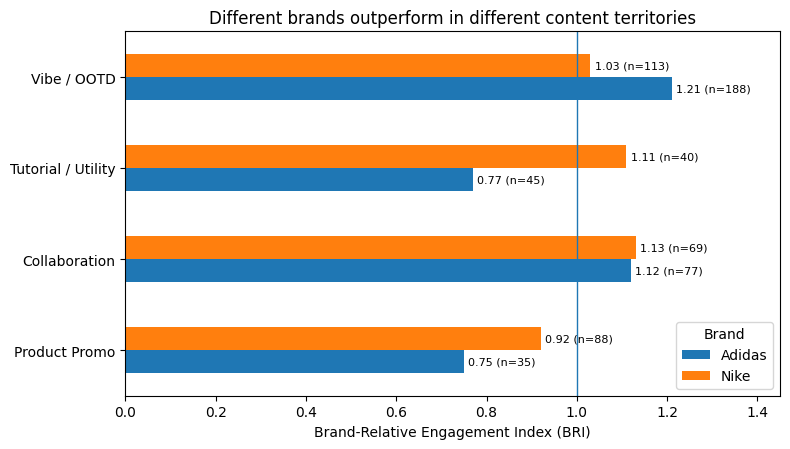

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Executive extract from the locked Theme 1 results.
theme1 = pd.DataFrame({
    "Brand": ["Adidas"] * 4 + ["Nike"] * 4,
    "Content territory": ["Vibe / OOTD","Tutorial / Utility","Collaboration","Product Promo"] * 2,
    "BRI": [1.21,0.77,1.12,0.75, 1.03,1.11,1.13,0.92],
    "n": [188,45,77,35, 113,40,69,88]
})

order = ["Product Promo","Collaboration","Tutorial / Utility","Vibe / OOTD"]
pivot = theme1.pivot(index="Content territory", columns="Brand", values="BRI").loc[order]
counts = theme1.pivot(index="Content territory", columns="Brand", values="n").loc[order]
ax = pivot.plot(kind="barh", figsize=(8,4.6))
for container, brand in zip(ax.containers, pivot.columns):
    ax.bar_label(container, labels=[f"{v:.2f} (n={n})" for v, n in zip(pivot[brand], counts[brand])],
                 padding=3, fontsize=8)
ax.set_xlim(0, 1.45)
ax.axvline(1.0, linewidth=1)
ax.set_xlabel("Brand-Relative Engagement Index (BRI)")
ax.set_ylabel("")
ax.set_title("Different brands outperform in different content territories")
plt.tight_layout()
plt.show()


### Transition
Attention is only the first layer. Once we know **what travels**, the next question is whether high-performing content is also **trying to sell**.

---
# 2 · CARRY COMMERCIAL INTENT
## High-performing TikTok is not simply “more promotional”

### Business question
**How much explicit commerce appears in the content—and does more selling correspond to stronger engagement?**

Commerce cues are sparse:

- **96.5%** of videos: **None**
- **3.5%**: Low
- Only **4 videos**: Medium
- **0**: High

Nike is more explicitly commerce-oriented in this sample:
- Mean commerce intensity: **Nike 0.050 vs Adidas 0.022**
- Low-commerce share: **4.7% vs 2.1%**

But engagement does **not** support a simple “more selling = better/worse” rule:
- None → median BRI **1.01**
- Low → **0.95**
- Medium → **0.87**, but **n = 4**
- Top-10% rate is actually **11.7% for Low vs 10.0% for None**

### The decision
**Commercial intent should be treated as a selective creative tactic.**  
The useful question is not “should we sell harder?” but **“where can commerce cues coexist with healthy engagement?”**


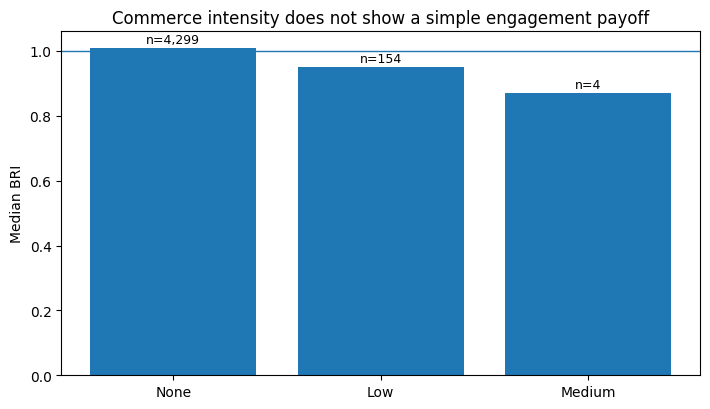

In [2]:
commerce = pd.DataFrame({
    "Commerce level": ["None","Low","Medium"],
    "Median BRI": [1.01,0.95,0.87],
    "n": [4299,154,4]
})

fig, ax = plt.subplots(figsize=(7.2,4.2))
ax.bar(commerce["Commerce level"], commerce["Median BRI"])
ax.axhline(1.0, linewidth=1)
ax.set_ylabel("Median BRI")
ax.set_title("Commerce intensity does not show a simple engagement payoff")
for i, r in commerce.iterrows():
    ax.text(i, r["Median BRI"] + 0.015, f'n={int(r["n"]):,}', ha="center", fontsize=9)
plt.tight_layout()
plt.show()


### Where the commercial signal becomes more useful
The aggregate average hides context.

**Higher-commerce + higher-BRI pockets** include:
- Collaboration
- OOTD / interactive clusters
- Air Max, AF1, Tracksuit, Superstar

**Higher-commerce + lower-BRI pockets** include:
- Product Promo
- Product Review
- Jordan cluster
- Samba / Gazelle

This is a **descriptive opportunity map**, not proof that changing commerce intensity causes engagement to move.

### Transition
If content and commercial intent work differently by context, the next decision is **who should carry the message**.


---
# 3 · CHOOSE THE MESSENGER
## Creator scale is not a strategy by itself

### Business question
**Should brands prioritize official accounts, UGC, or larger creators?**

The creator ecosystem tells a more useful story than a simple follower ranking:

- **71.5% UGC** vs **28.5% official**
- Official content has higher median reach: ~**130k vs 99k views**
- UGC has higher median BRI: **1.09 vs 0.80**
- Nike has a larger official share (**34.0%**) than Adidas (**22.7%**)
- Adidas has a larger UGC share (**77.3%**) than Nike (**66.0%**)

Most importantly:

> **No UGC creator tier is uniformly strongest.**

Vibe/OOTD and Lifestyle travel across Nano–Mid creators, while Collaboration, Technical and Performance are more tier-dependent.

### Collaboration signal
Collaboration language appears in only **146 videos (3.3%)**, but those videos show:
- Median BRI **1.13 vs 1.00**
- Median WER **0.74% vs 0.64%**
- Lower median views (~83k vs ~115k)

This is association, not verified sponsorship impact.

### The decision
**Optimize creator–content fit, not follower count alone.**


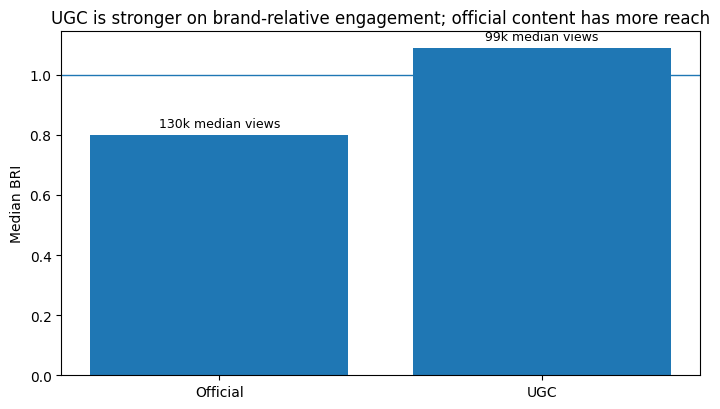

In [3]:
creator = pd.DataFrame({
    "Channel": ["Official","UGC"],
    "Median BRI": [0.80,1.09],
    "Median views (000s)": [130,99]
})

fig, ax = plt.subplots(figsize=(7.2,4.2))
ax.bar(creator["Channel"], creator["Median BRI"])
ax.axhline(1.0, linewidth=1)
ax.set_ylabel("Median BRI")
ax.set_title("UGC is stronger on brand-relative engagement; official content has more reach")
for i, r in creator.iterrows():
    ax.text(i, r["Median BRI"] + 0.025,
            f'{r["Median views (000s)"]:.0f}k median views',
            ha="center", fontsize=9)
plt.tight_layout()
plt.show()


### Transition
Content has earned attention, commercial intent has been layered in, and creators have carried the message.  
The final business question is: **what did the audience actually respond to?**

---
# 4 · READ THE RESPONSE
## Overall sentiment is less useful than knowing where perception strengthens or breaks down

### Business question
**What do people react positively to—and where does friction appear?**

This section uses comments from **105 high-engagement videos (~10.4k comments)**.  
It is a diagnostic subsample, **not** a full Nike/Adidas audience survey.

Overall:
- **Adidas:** 42.6% positive / 16.2% negative
- **Nike:** 36.8% positive / 17.6% negative

But the aggregate score is not the real insight.

### Topic-level signals
- **Vibe / OOTD:** positive conversation for both brands
- **Product Review:** substantially warmer for Adidas; Nike is more polarized
- **Fit & Comfort:** clearer Adidas advantage
- **Availability / Access:** more Adidas negativity
- **Purchase Desire:** Adidas has more positive *and* more negative conversation, leaving net sentiment close to Nike

Only about **29%** of comments map to substantive commercial/product topics; a large share is social reaction, lightweight reaction, or Other / Unclear.

### The decision
**Use TikTok comments as a diagnostic listening layer—not as one brand-wide sentiment score.**


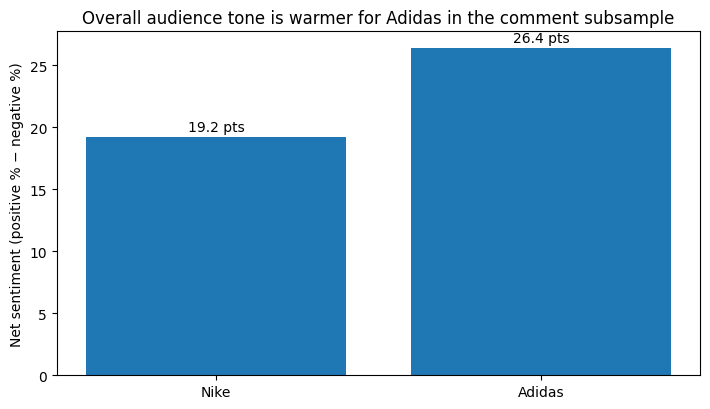

In [4]:
sent = pd.DataFrame({
    "Brand": ["Nike","Adidas"],
    "Positive": [36.8,42.6],
    "Negative": [17.6,16.2]
})
sent["Net"] = sent["Positive"] - sent["Negative"]

fig, ax = plt.subplots(figsize=(7.2,4.2))
ax.bar(sent["Brand"], sent["Net"])
ax.set_ylabel("Net sentiment (positive % − negative %)")
ax.set_title("Overall audience tone is warmer for Adidas in the comment subsample")
for i, r in sent.iterrows():
    ax.text(i, r["Net"] + 0.5, f'{r["Net"]:.1f} pts', ha="center")
plt.tight_layout()
plt.show()


---
# 5 · THE BUSINESS STORY
## Four analyses become one decision framework

The four themes are not independent dashboards. They answer consecutive decisions:

### 1. **EARN ATTENTION**
Identify the content territories that perform strongly **relative to each brand's baseline**.

↓  

### 2. **CARRY COMMERCIAL INTENT**
Determine where explicit commerce can be introduced **without assuming that harder selling creates engagement**.

↓  

### 3. **CHOOSE THE MESSENGER**
Match creator scale and channel to the content strategy instead of using follower count as the decision rule.

↓  

### 4. **READ THE RESPONSE**
Use topic-level audience conversation to identify what to **reinforce**, what to **investigate**, and where friction is product-specific.

## The resulting strategy
### **Observe → Compare → Hypothesize → Test**

The data does **not** identify a universal TikTok formula.  
It does identify **where the next experiment should start**.


---
# 6 · FROM INSIGHT TO ACTION
## What should each brand investigate next?

### Adidas
**Protect / reinforce**
- Lifestyle, styling and Vibe/OOTD are established relative strengths.
- Fit & Comfort conversation is comparatively warm.

**Investigate**
- Availability / Access friction.
- Whether strong lifestyle engagement converts into useful product discovery without requiring heavier promotional language.

**Test**
- Creator-led lifestyle executions that preserve the platform-native feel while selectively introducing product/commercial cues.

### Nike
**Protect / reinforce**
- Technical / Tutorial-Utility and Collaboration are stronger relative territories.
- Performance positioning remains strategically distinctive.

**Investigate**
- More polarized Product Review conversation.
- Whether Nike's higher commerce orientation is concentrated in formats that underperform the brand baseline.

**Test**
- Utility-led and collaboration-led creative against harder Product Promo executions.

### Across both brands
**Do not optimize one variable in isolation.**  
The next experiment should specify:

**Content territory × Commerce intensity × Creator profile × Audience response hypothesis**

That is the unit of strategy suggested by the analysis.


---
# 7 · WHAT NOT TO CLAIM

This report intentionally avoids several tempting but unsupported conclusions:

- ❌ “Adidas is better than Nike on TikTok.”
- ❌ “Commerce reduces engagement.”
- ❌ “Micro creators outperform macro creators.”
- ❌ “Collaboration causes higher engagement.”
- ❌ “Positive sentiment means purchase intent.”
- ❌ “These findings represent all TikTok users.”

Use:
- **“in this sample”**
- **“associated with”**
- **“above/below brand baseline”**
- **“worth testing”**
- **“diagnostic signal”**

This preserves the commercial usefulness of the findings without turning observational analysis into causal claims.


---
# Appendix · Where the evidence lives

This executive report is deliberately selective.

| Detailed evidence | Source notebook |
|---|---|
| EDA, distributions, coverage | `01_eda.ipynb` |
| Content strategy & within-brand BRI | `02_descriptive_crosstabs.ipynb` |
| Predictive screening / CatBoost / SHAP | `03_engagement_modeling.ipynb` |
| Awareness write-up | `04a_theme_awareness.ipynb` |
| Commerce intensity & matrices | `04b_theme_commerce.ipynb` |
| Creator tiers & collaboration | `04c_theme_influencer.ipynb` |
| Comment sentiment & topics | `04d_theme_sentiment.ipynb` |

### What belongs in this report
**6–8 decision-grade visuals, headline findings, transitions, implications.**

### What stays in the technical notebooks
Full distributions, every crosstab, statistical tests, taxonomy diagnostics, robustness checks, model diagnostics and implementation detail.

> The executive layer communicates the decision story; the detailed notebooks preserve the analytical evidence trail.
